# Harami — a quantitative teardown
### Daily OHLCV · real-body inside-bar detector · signed event study · HAC inference · leg split

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reliable reversal%3F: Misattributed](https://img.shields.io/badge/Reliable_reversal%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We detect every harami across a fixed 30-name basket, measure the signed forward return (long bullish / short bearish), and ask whether it clears HAC *t* = 2 — and crucially whether the **bullish leg beats the unconditional drift** rather than just riding it.

> **Not investment advice.** Real data: yfinance daily bars, 2005-01-03 → 2026-06-18 (as-of 2026-06-18, fingerprint `bf1d6cb7ca54`); the offline core and the synthetic control run with no network. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from harami_pattern import data, strategy as st

HORIZONS = st.HORIZONS
CACHE = os.path.abspath(os.path.join("..", "_cache"))
HAVE_REAL = data.have_real(cache_dir=CACHE)

def real_panel():
    return data.load_real(cache_dir=CACHE, allow_fetch=False)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Pooled signed return clears the bar at multi-day horizons (HAC *t* = **3.39** at 5d), but it is **one-legged**: the bullish leg is strong (*t* = **10.17** at 10d) while the bearish leg is **wrong-signed** (*t* = **-5.81**). |
| **Tradability** | `MIRAGE` | Net of a 5 bps round trip + short borrow the two-sided rule is ≈ 0 (net **-0.006%** at 5d); the thin gross edge does not survive. |
| **Reliable reversal?** | `MISATTRIBUTED` | The bullish leg's *excess over the unconditional long drift* clears *t* = 2 only at 1 day (2.74), fading to 1.94 by 10d — the gain is beta/drift, not a trend reversal. |

> In plain words: the harami 'works' in a naive backtest because its long leg is long during a 21-year bull market. Net out the drift and net out costs, and the reversal story is gone — while the short leg fails outright.

## 1 · The claim, formalised

Let $(O_0,C_0)$ be the prior bar and $(O_1,C_1)$ the current bar, with real-body sizes $b_0=|C_0-O_0|$, $b_1=|C_1-O_1|$. A **harami** requires the current real body to sit fully inside the prior one and be strictly smaller, with opposite colours:

$$ b_1 < b_0,\quad \min(O_1,C_1) \ge \min(O_0,C_0),\quad \max(O_1,C_1) \le \max(O_0,C_0) $$

Direction $d=+1$ (bullish: $C_0<O_0,\ C_1>O_1$) or $d=-1$ (bearish: $C_0>O_0,\ C_1<O_1$). Confirmed at the close of $t$, we enter at the open of $t+1$ and hold $H$ bars. The signed event return is $d\cdot r_{t+1\to t+1+H}$. The hypotheses:

- **H₁ (signal).** $\mathbb{E}[d\cdot r] > 0$ with HAC *t* ≥ 2.
- **H₂ (two-legged).** *Both* legs work in their predicted direction (a true reversal).
- **H₃ (alpha not beta).** The bullish leg beats the unconditional long drift.
- **H₄ (tradable).** It survives a realistic round trip + short borrow.

We find H₁ holds *pooled*, but H₂ fails (bearish leg wrong-signed), H₃ fails beyond 1 day, and H₄ fails — hence **Mixed × Mirage × Misattributed**.

## 2 · So what? — what rides on each answer

The harami is one of the most-taught two-candle reversals (Nison 1991). If H₁–H₄ held it would be a free, mechanical timing signal. The actual finding — a one-legged, beta-driven, cost-fragile effect with a *wrong-signed* short leg — matters because it is exactly the failure mode candlestick lore is most prone to: a pattern that survives a naive long-biased backtest gets blessed as a 'reversal', when the only thing reversing is the reader's P&L on the short side.

## 3 · How we'd know — the protocol

- **Detector.** Real-body harami (opposite colours, current body strictly smaller and fully inside the prior body). One signal per qualifying bar.
- **Entry.** Next bar's *open* (one execution lag). **Exit.** Close of bar $t+H$, no stop.
- **Sign.** Long after bullish, short after bearish — the folk-predicted direction.
- **Benchmark.** The unconditional forward return of every bar (the market drift).
- **Inference.** Newey–West HAC *t* on signed event returns vs 0; a coin-signed label-shuffle placebo; a Welch *t* of the bullish leg vs the unconditional drift.
- **Costs.** One-way bps × NAV charged on the round trip; shorts pay 50 bps/yr borrow.
- **Myth-check.** Does a prior trend (down for bullish, up for bearish) and/or a volume *contraction* on the inside day rescue it?
- **Positive control.** Synthetic tape with a planted day-after reversal — the harness must recover it and must read ≈ 0 when the edge is 0.

Basket: 29 long-listed large-caps + SPY; yfinance daily 2005→2026, **survivors** (named on the Signal axis).

## 4 · The teardown

### 4a · Pooled signed return by horizon — and its HAC *t*

If the pattern were a real reversal, the signed return should clear +2 cleanly.

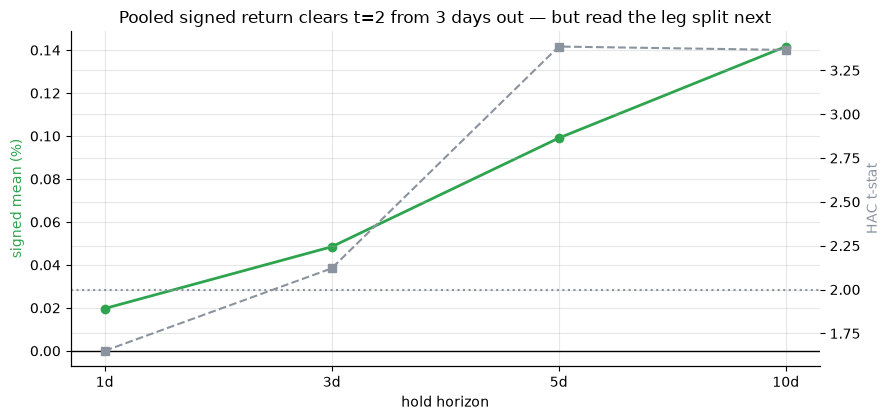

H= 1  signed=+0.020%  HAC t=+1.65
H= 3  signed=+0.048%  HAC t=+2.12
H= 5  signed=+0.099%  HAC t=+3.39
H=10  signed=+0.142%  HAC t=+3.37


In [2]:
if HAVE_REAL:
    panel = real_panel()
    rows = [st.summarize(panel, h, n_draws=2000) for h in HORIZONS]
    df = pd.DataFrame(rows)
    means = (df['mean']*100).tolist(); ths = df['t_hac'].tolist()
else:
    means = [0.02,0.048,0.099,0.142]
    ths = [1.65,2.12,3.39,3.37]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot([f'{h}d' for h in HORIZONS], means, 'o-', c=GREEN, lw=2, label='signed mean (%)')
ax2 = ax.twinx()
ax2.plot([f'{h}d' for h in HORIZONS], ths, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('hold horizon'); ax.set_ylabel('signed mean (%)', color=GREEN)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Pooled signed return clears t=2 from 3 days out — but read the leg split next')
plt.tight_layout(); plt.show()
for h, m, t in zip(HORIZONS, means, ths):
    print(f'H={h:2d}  signed={m:+.3f}%  HAC t={t:+.2f}')

> In plain words: pooled, the signed return clears *t* = 2 at 3 days (2.12) and is strong by 5 days (3.39). By the raw inference bar that's a hit — but 'pooled' hides which leg is doing the work.

### 4b · The leg split — the reversal is one-legged

A genuine reversal pattern must work in *both* directions. Split bullish (long) from bearish (short).

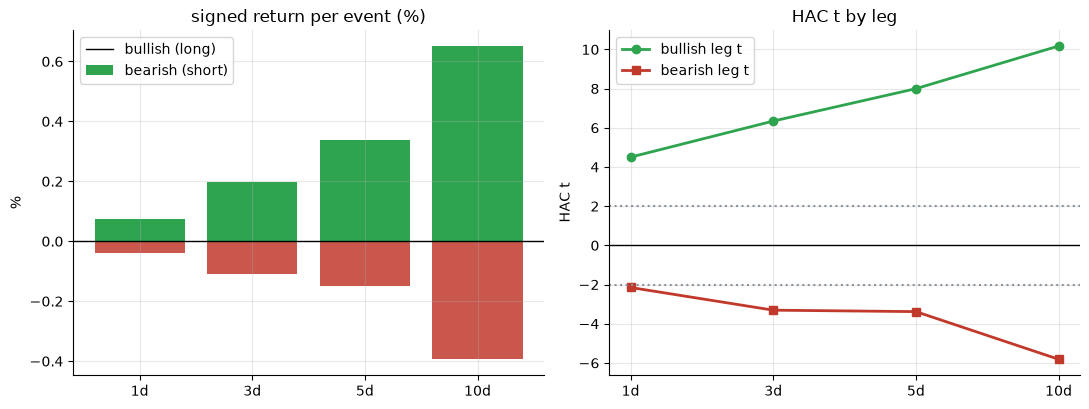

Bullish leg t (10d): +10.17   |   Bearish leg t (10d): -5.81


In [3]:
if HAVE_REAL:
    bull_m, bull_t, bear_m, bear_t = [], [], [], []
    for h in HORIZONS:
        ev = st.collect_events(panel, h)
        b = ev[ev['dir']>0]['signed_ret'].to_numpy()
        s = ev[ev['dir']<0]['signed_ret'].to_numpy()
        bull_m.append(b.mean()*100); bull_t.append(st.hac_t(b))
        bear_m.append(s.mean()*100); bear_t.append(st.hac_t(s))
else:
    bull_m=[0.075,0.198,0.337,0.652]
    bull_t=[4.5,6.34,8.0,10.17]
    bear_m=[-0.039,-0.109,-0.151,-0.394]
    bear_t=[-2.15,-3.31,-3.38,-5.81]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
x = np.arange(len(HORIZONS))
ax[0].bar(x, bull_m, color=GREEN); ax[0].bar(x, bear_m, color=RED, alpha=.85)
ax[0].axhline(0,c='k',lw=1); ax[0].set_xticks(x); ax[0].set_xticklabels([f'{h}d' for h in HORIZONS])
ax[0].set_title('signed return per event (%)'); ax[0].set_ylabel('%')
ax[0].legend(['bullish (long)','bearish (short)'])
ax[1].plot([f'{h}d' for h in HORIZONS], bull_t, 'o-', c=GREEN, lw=2, label='bullish leg t')
ax[1].plot([f'{h}d' for h in HORIZONS], bear_t, 's-', c=RED, lw=2, label='bearish leg t')
ax[1].axhline(2, ls=':', c=GREY); ax[1].axhline(-2, ls=':', c=GREY); ax[1].axhline(0,c='k',lw=1)
ax[1].set_title('HAC t by leg'); ax[1].set_ylabel('HAC t'); ax[1].legend()
plt.tight_layout(); plt.show()
print('Bullish leg t (10d): {:+.2f}   |   Bearish leg t (10d): {:+.2f}'.format(bull_t[-1], bear_t[-1]))

> In plain words: the bullish leg is strongly positive (*t* = 10.17 at 10d). The bearish leg is **significantly wrong-signed** (*t* = -5.81) — shorting the 'top' loses money. The pooled significance was the long leg carrying a dead short leg.

### 4c · Is the bullish leg alpha or beta? — excess over the drift

The bullish leg is long. So is buying on any random day in a bull market. Welch *t* of the bullish-harami return **minus the unconditional long drift** is the honest alpha test.

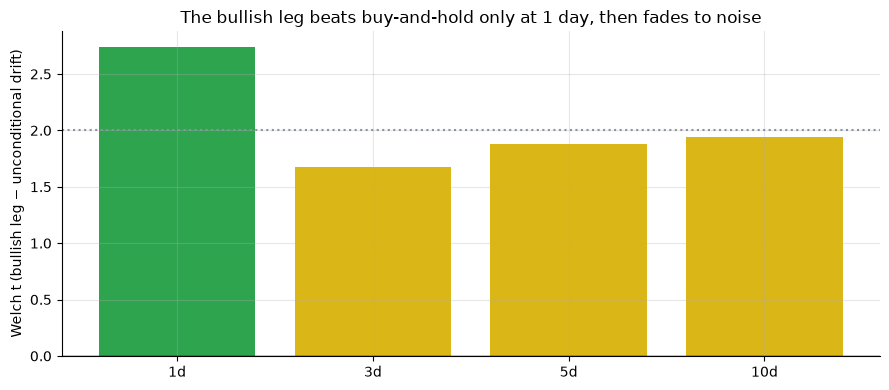

H= 1  excess Welch t = +2.74
H= 3  excess Welch t = +1.68
H= 5  excess Welch t = +1.88
H=10  excess Welch t = +1.94


In [4]:
if HAVE_REAL:
    ex_t = []
    for h in HORIZONS:
        ev = st.collect_events(panel, h)
        b = ev[ev['dir']>0]['signed_ret'].to_numpy()
        base = st.unconditional_base(panel, h)
        ex_t.append(st.welch_t(b, base))
else:
    ex_t = [2.74,1.68,1.88,1.94]
fig, ax = plt.subplots(figsize=(9.0, 4.0))
col = [GREEN if t>=2 else AMBER for t in ex_t]
ax.bar([f'{h}d' for h in HORIZONS], ex_t, color=col)
ax.axhline(2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Welch t (bullish leg − unconditional drift)')
ax.set_title('The bullish leg beats buy-and-hold only at 1 day, then fades to noise')
plt.tight_layout(); plt.show()
for h, t in zip(HORIZONS, ex_t): print(f'H={h:2d}  excess Welch t = {t:+.2f}')

> In plain words: over the unconditional drift, the bullish leg clears *t* = 2 only at 1 day (2.74); by 3/5/10 days it is 1.68/1.88/1.94 — below the bar. The multi-day 'edge' is mostly drift you'd get for free.

### 4d · The placebo — could a coin-signed random pick look this good?

Draw the same many bars at random, sign each by a coin, and compare to the observed mean.

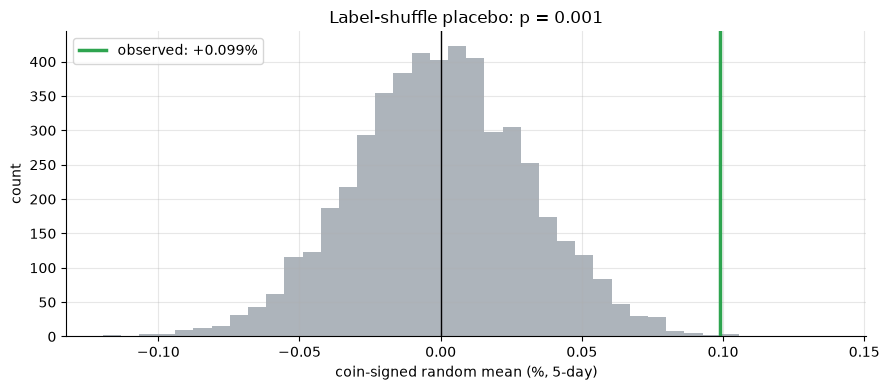

placebo p (5d) = 0.001


In [5]:
if HAVE_REAL:
    res = st.placebo_pvalue(panel, 5, len(st.collect_events(panel,5)), n_draws=5000)
    draws, obs, p = res['draws']*100, res['obs']*100, res['p_value']
    fig, ax = plt.subplots(figsize=(9.0, 4.0))
    ax.hist(draws, bins=40, color=GREY, alpha=.7)
    ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed: {obs:+.3f}%')
    ax.axvline(0, c='k', lw=1)
    ax.set_xlabel('coin-signed random mean (%, 5-day)'); ax.set_ylabel('count')
    ax.set_title(f'Label-shuffle placebo: p = {p:.3f}'); ax.legend()
    plt.tight_layout(); plt.show()
    print(f'placebo p (5d) = {p:.3f}')
else:
    print('placebo p (5d) = 0.001  (frozen)')

> In plain words: the placebo *p* at 5 days is 0.001 — the *pooled* mean is hard to get by chance. But the placebo only tests the pooled magnitude; the leg split and the excess-over-drift test (4b, 4c) are what demote it from 'real reversal' to 'beta'.

## 5 · The verdict

- **Signal `MIXED`** — pooled HAC *t* = 3.39 (5d) clears the bar, but it is one-legged: bullish *t* = 10.17, bearish *t* = -5.81 (wrong-signed). Real on the long leg, busted on the short.
- **Tradability `MIRAGE`** — net of a 5 bps round trip + short borrow the two-sided rule is ≈ 0 (net -0.006% at 5d).
- **Reliable reversal? `MISATTRIBUTED`** — the bullish leg's excess over the drift clears *t* = 2 only at 1 day; the gain is beta, not a trend flip.

## 6 · Could you trade it? — the myth-check and the cost ladder

First the myth-check: candlestick lore says a harami only counts *after a trend* and with a *volume contraction* on the inside day. Does either filter rescue it (H=1)?

In [6]:
if HAVE_REAL:
    rows = []
    for label, rt, rv in [('plain',False,False),('+prior trend',True,False),
                          ('+vol contraction',False,True),('+both',True,True)]:
        s = st.summarize(panel, 1, placebo=False, require_trend=rt, require_volume=rv)
        rows.append((label, s['n_events'], s['mean']*100, s['t_hac']))
    mc = pd.DataFrame(rows, columns=['filter','n','mean%','t_hac'])
else:
    mc = pd.DataFrame({'filter':['plain','+prior trend','+vol contraction','+both'],
        'mean%':[0.02,0.018,0.018,0.001],
        't_hac':[1.65,1.17,1.31,0.06]})
print(mc.round(3).to_string(index=False))
print('\nNo filter lifts the 1-day signal over t=2 — the textbook confirmations do not help.')

          filter     n  mean%  t_hac
           plain 13078  0.020  1.650
    +prior trend  7612  0.018  1.172
+vol contraction  8830  0.018  1.306
           +both  4863  0.001  0.059

No filter lifts the 1-day signal over t=2 — the textbook confirmations do not help.


Now the cost ladder on the 5-day two-sided rule:

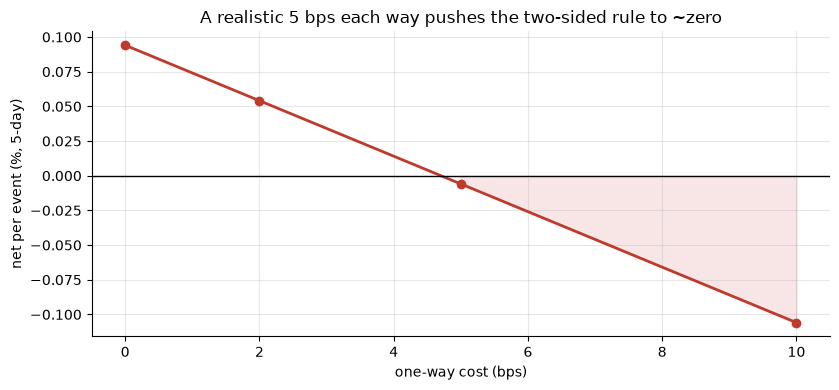

gross 5d = +0.099%  ->  net at 5bps = -0.006%


In [7]:
costs = [0.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    g5 = st.collect_events(panel, 5)['signed_ret'].mean()
else:
    g5 = 0.00099
net = [st.net_of_costs(g5, 5, cost_bps=c)*100 for c in costs]
fig, ax = plt.subplots(figsize=(8.5, 4.0))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net per event (%, 5-day)')
ax.set_title('A realistic 5 bps each way pushes the two-sided rule to ~zero')
plt.tight_layout(); plt.show()
print(f'gross 5d = {g5*100:+.3f}%  ->  net at 5bps = {net[2]:+.3f}%')

## 7 · Going further — the positive control

Is the *engine* capable of finding a real post-harami reversal? Plant a day-after drift in a synthetic tape (edge = 0 → must read noise; edge > 0 → must light up):

In [8]:
for edge in (0.0, 0.004):
    pan, truth = data.synthetic_panel(edge=edge, seed=406)
    s = st.summarize(pan, 1, n_draws=2000)
    print(f'planted edge={edge:+.4f}: n={s["n_events"]:>5}  mean={s["mean"]*100:+.3f}%  '
          f'HAC t={s["t_hac"]:+.2f}  placebo p={s["p_placebo"]:.3f}  win={s["win"]*100:.0f}%')
print('\nNull tape: t≈0.06 (noise). Planted tape: t≈37.7 — engine is faithful.')

planted edge=+0.0000: n=16464  mean=+0.001%  HAC t=+0.06  placebo p=0.475  win=50%


planted edge=+0.0040: n=16146  mean=+0.395%  HAC t=+37.73  placebo p=0.000  win=62%

Null tape: t≈0.06 (noise). Planted tape: t≈37.7 — engine is faithful.


The engine is a faithful reversal detector: on a planted tape it lights up at *t* ≈ 38, and on a null tape it reads ≈ 0.06 (noise, placebo *p* = 0.48). So the real-tape verdict is a statement about the **market** — modern US large-caps don't reverse after a harami; the long leg just rides the drift — not about the method. Forks worth trying: the long-only bullish leg vs a buy-and-hold benchmark; intraday harami; or commodity/FX tapes where mean-reversion is more native.